In [1]:
#import relevant libraries: pip install re, pip install natsort, pip install plotly==5.10.0
import sys
import os
import glob

import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import datetime as dt8
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import decimal
import re
from natsort import index_natsorted
import dabest

import itertools
import NLCLIMB 
import NLGRAPHS
import NLMATH
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')

import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout

from scipy.optimize import curve_fit

#NOTE: SUPPRESSES WARNINGS!

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 14.85it/s]


Numba compilation complete!


In [2]:
def counterfall(df_rr1, nnumber, nnumberwt, phase): #phase is either "wt" or "expt"
    
    df_rr1['integer'] = df_rr1['value'].astype(int)
    count_wtfull = df_rr1[(df_rr1["Type"] == phase)]['integer'].value_counts()
    count_wtfull = count_wtfull.rename_axis('integer').reset_index(name='counts')

    if phase == "WT":
        dvis = nnumberwt
    else:
        dvis = nnumber
    count_wtfull['counts'] = (count_wtfull['counts']/dvis)*100
    
    listofval = [x for x in [float(x) for x in range(0,23)] if x not in set(count_wtfull['integer'])]
    count_wtfull = pd.concat([count_wtfull, pd.DataFrame({"integer" :listofval})], ignore_index = True)

    count_wtfull = count_wtfull.sort_values(by=['integer']).reset_index(drop = True)
    count_wtfull['counts'] = count_wtfull['counts'].replace(np.nan, 0)
    count_wtfull['name'] = phase
    
    return count_wtfull

def removingextraline(df1):  #only takes 22 seconds of the entire timeline
    df = df1.reset_index(drop=True)
    df['Seconds'] = round(df['Seconds'],1)
    line = df[(df['Seconds'] > 22.0)].index
    df = df.drop(line)
    
    return df

In [6]:
#initial file processing

workcomp = "C:\\Users\\User"
laptop = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
specifiedpath = homecomp

#Comment depending on project type

eopn3work = 'tgt'

# if eopn3work == "Y":
#     whomst = "Leif"
#     filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\2. Processed\\" + whomst + "\\"
#     savefiglocation = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\"

if eopn3work == "tgt":
    filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Together\\2. Processed\\"
    savefiglocation = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Together\\"
   
    
openPath = specifiedpath + filedir
files = os.listdir(openPath)

#identifying genotypes
responder = "ACR"     
driver = "OK371"
wt = "w1118"
transgenic = driver + " x " + responder
filename = openPath + transgenic + ".csv"
filenamewt = openPath + wt+"_"+ transgenic + ".csv"

print(filename)
print(filenamewt)

dfe=pd.read_csv(filename)
dfw= pd.read_csv(filenamewt)

exptdf = dfe.drop(dfe.columns[[0]],axis = 1)
wtdf = dfw.drop(dfw.columns[[0]],axis = 1)

dfexpt = NLCLIMB.generation(exptdf, driver)
dfwt = NLCLIMB.generation(wtdf, wt)

# Set up Inter font
font_dirs = ["fonts"]  # local Inter TTFs in the repo

# Register fonts
import matplotlib.font_manager as fm
for font_file in fm.findSystemFonts(fontpaths=font_dirs):
    fm.fontManager.addfont(font_file)

# Set Inter as default font
plt.rcParams['font.family'] = 'Inter'

D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\eOPN3 manuscript\Data compilation\Together\2. Processed\OK371 x ACR.csv
D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\eOPN3 manuscript\Data compilation\Together\2. Processed\w1118_OK371 x ACR.csv


# **TOTAL calculations for graphs**



In [7]:
#Y position
df_de = NLMATH.calcgraph(dfexpt,"Y.*")
df_meande=NLMATH.meangraph(df_de)
df_dw = NLMATH.calcgraph(dfwt,"Y.*")
df_meandw=NLMATH.meangraph(df_dw)

#speed
df_se = NLMATH.calcgraph(dfexpt, "Velocity.*")
df_meanse = NLMATH.meangraph(df_se)
df_sw = NLMATH.calcgraph(dfwt, "Velocity.*")
df_meansw = NLMATH.meangraph(df_sw)

#Falling
df_fed = NLMATH.fallcalc(dfexpt, "Dark")
df_fel = NLMATH.fallcalc(dfexpt, "Full")
df_fer = NLMATH.fallcalc(dfexpt, "Recovery")

df_fwd = NLMATH.fallcalc(dfwt, "Dark")
df_fwl = NLMATH.fallcalc(dfwt, "Full")
df_fwr = NLMATH.fallcalc(dfwt, "Recovery")

#Falling
df_re = NLMATH.rastergraph(dfexpt)
df_rw = NLMATH.rastergraph(dfwt)
df_re['Type'] = "EXPT"
df_rw['Type'] = "WT"

df_rrdark = pd.concat([df_re[(df_re['ExperimentState']== 'Dark')], df_rw[(df_rw['ExperimentState']== 'Dark')]]).reset_index(drop=True)
#df_rr['list']= range(1,len(df_rr)+1)
df_rrfull = pd.concat([df_re[(df_re['ExperimentState']== 'Full')], df_rw[(df_rw['ExperimentState']== 'Full')]]).reset_index(drop=True)
#df_rr1['list']= range(1,len(df_rr1)+1)
df_rrrec = pd.concat([df_re[(df_re['ExperimentState']== 'Recovery')], df_rw[(df_rw['ExperimentState']== 'Recovery')]]).reset_index(drop=True)

## figure generation

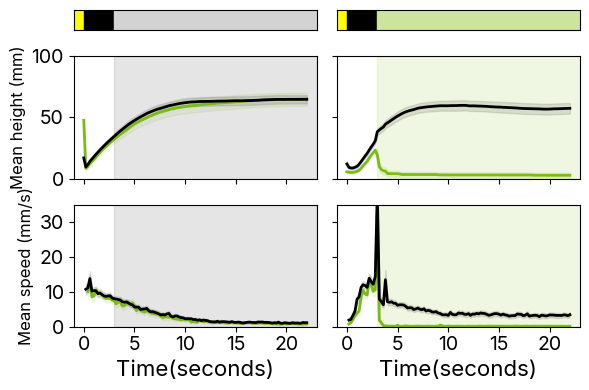

In [9]:
import matplotlib.patches as patches
figfirstplot, axs = plt.subplots(3, 2, figsize=(6, 4 ),sharex = "col", sharey = "row", gridspec_kw={'height_ratios': [1,6,6]}) #sharey = row


df3 = removingextraline(df_meande)
df4 = removingextraline(df_meandw)
df5 = removingextraline(df_meanse)
df6 = removingextraline(df_meansw)

    
nnumber = int(0.20*(len(dfexpt.columns)-2))
nnumberwt = int(0.20*(len(dfwt.columns)-2))
time = df3.loc[df3.ExperimentState == "Dark", 'Seconds']
time2 = df4.loc[df4.ExperimentState == "Dark", 'Seconds']

if "ACR" in responder or "eOPN3" in responder:
    barcolr = "#7BBB14"  # # color = "#19BBDFFF" for eopn3 #7BBB14 for acr
    patchcolor = "#cde49d"
    compdark = "#73440f"
    complight = "#de841f"
    responderrename = responder.replace("eOPN3", "AsOPN3")
    transgenicname = driver + " x " + responderrename
    
    
elif "PdCO" in responder:
    barcolr = "#0080ff"
    patchcolor = "#7abdff"
    compdark = "#3d07b0"
    complight = "#b495f5"
    transgenicname = driver + " x " + responder

#cartoon
axs[0,0].axvspan(-1,0, color = "#FFFF00", label = "_nolegend_")
axs[0,0].axvspan(0,3, color = "#000000", label = "_nolegend_")
axs[0,0].axvspan(3,23, color = "lightgray" , label = "_nolegend_")

axs[0,1].axvspan(-1,0, color = "#FFFF00" , label = "_nolegend_")
axs[0,1].axvspan(0,3, color = "#000000", label = "_nolegend_")
axs[0,1].axvspan(3,23, color = patchcolor, label = "_nolegend_")

axs[0,0].get_yaxis().set_visible(False)
axs[0,1].get_yaxis().set_visible(False)

axs[0,0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
axs[0,1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
#y pos    

axs[1,0].axvspan(3,23, alpha=0.1, color = "#000000", label = "_nolegend_")

axs[1,0].plot(time, df3.loc[df3.ExperimentState == "Dark", 'mean'], color = barcolr, linewidth = 2, label = "transgenicname")
axs[1,0].fill_between(time, (df3.loc[df3.ExperimentState == "Dark", 'mean']-df3.loc[df3.ExperimentState == "Dark", 'CI']), 
                      df3.loc[df3.ExperimentState == "Dark", 'mean']+df3.loc[df3.ExperimentState == "Dark", 'CI'], color= barcolr, alpha=.1, label = "_nolegend_")
axs[1, 0].plot(time, df4.loc[df4.ExperimentState == "Dark", 'mean'], color = "#000000", linewidth =2, label = "w1118 controls")
axs[1,0].fill_between(time, (df4.loc[df4.ExperimentState == "Dark", 'mean']-df4.loc[df4.ExperimentState == "Dark", 'CI']), 
                      df4.loc[df4.ExperimentState == "Dark", 'mean']+df4.loc[df4.ExperimentState == "Dark", 'CI'], color= "#000000", alpha=.1, label = "_nolegend_")
axs[1,0].set_ylabel('Mean height (mm)', fontsize=12)



axs[1,1].axvspan(3,23, alpha=0.3, color = patchcolor, label = "_nolegend_")

axs[1,1].plot(time, df3.loc[df3.ExperimentState == "Full", 'mean'], color = barcolr, linewidth = 2, label = "_nolegend_")
axs[1,1].fill_between(time, (df3.loc[df3.ExperimentState == "Full", 'mean']-df3.loc[df3.ExperimentState == "Full", 'CI']), 
                      df3.loc[df3.ExperimentState == "Full", 'mean']+df3.loc[df3.ExperimentState == "Full", 'CI'], color= barcolr, alpha=.1, label = "_nolegend_")
axs[1,1].plot(time, df4.loc[df4.ExperimentState == "Full", 'mean'], color = "#000000", linewidth =2, label = "_nolegend_")
axs[1,1].fill_between(time, (df4.loc[df4.ExperimentState == "Full", 'mean']-df4.loc[df4.ExperimentState == "Full", 'CI']), 
                      df4.loc[df4.ExperimentState == "Full", 'mean']+df4.loc[df4.ExperimentState == "Full", 'CI'], color= "#000000", alpha=.1, label = "_nolegend_")

# axs[1,2].axvspan(3,23, alpha=0.3, color = patchcolor, label = "_nolegend_")


axs[1,0].set_ylim([0, 100])
axs[1,1].set_ylim([0, 100])


#speed
#df5 is expt
#df6 is wt
time = df5.loc[df5.ExperimentState == "Dark", 'Seconds']
time2 = df6.loc[df6.ExperimentState == "Dark", 'Seconds']

axs[2,0].axvspan(3,23, alpha=0.1, color = "#000000", label = "_nolegend_")
axs[2,1].axvspan(3,23, alpha=0.3, color = patchcolor, label = "_nolegend_")


axs[2,0].plot(time, df5.loc[df5.ExperimentState == "Dark", 'mean'], color = barcolr, linewidth = 2, label = transgenicname)
axs[2,0].fill_between(time, (df5.loc[df5.ExperimentState == "Dark", 'mean']-df5.loc[df5.ExperimentState == "Dark", 'CI']), 
                      df5.loc[df5.ExperimentState == "Dark", 'mean']+df5.loc[df5.ExperimentState == "Dark", 'CI'], color= barcolr, alpha=.1,  label = "_nolegend_")

axs[2,0].plot(time, df6.loc[df6.ExperimentState == "Dark", 'mean'], color = "#000000", linewidth =2, label = "w1118 controls")
axs[2,0].fill_between(time, (df6.loc[df6.ExperimentState == "Dark", 'mean']-df6.loc[df6.ExperimentState == "Dark", 'CI']), 
                      df6.loc[df6.ExperimentState == "Dark", 'mean']+df6.loc[df6.ExperimentState == "Dark", 'CI'], color= "#000000", alpha=.1, label = "_nolegend_")
axs[2,0].set_ylabel('Mean speed (mm/s)', fontsize=12)


axs[2,1].plot(time, df5.loc[df5.ExperimentState == "Full", 'mean'], color = barcolr, linewidth = 2, label = "_nolegend_")
axs[2,1].fill_between(time, (df5.loc[df5.ExperimentState == "Full", 'mean']-df5.loc[df5.ExperimentState == "Full", 'CI']), 
                      df5.loc[df5.ExperimentState == "Full", 'mean']+df5.loc[df5.ExperimentState == "Full", 'CI'], color= barcolr, alpha=.1, label = "_nolegend_")
axs[2,1].plot(time, df6.loc[df6.ExperimentState == "Full", 'mean'], color = "#000000", linewidth =2, label = "_nolegend_")
axs[2,1].fill_between(time, (df6.loc[df6.ExperimentState == "Full", 'mean']-df6.loc[df6.ExperimentState == "Full", 'CI']), 
                      df6.loc[df6.ExperimentState == "Full", 'mean']+df6.loc[df6.ExperimentState == "Full", 'CI'], color= "#000000", alpha=.1, label = "_nolegend_")


axs[2,0].set_ylim([0, 35])
axs[2,0].set_yticks(np.arange(0, 36, 10))
axs[2,1].set_ylim([0, 35])
axs[2,1].set_yticks(np.arange(0, 36, 10))


axs[2,0].set_xlabel('Time(seconds)', fontsize=16)
axs[2,1].set_xlabel('Time(seconds)', fontsize=16)


# axs[2,0].tick_params(axis='x', labelsize=14)
# axs[2,1].tick_params(axis='x', labelsize=14)

# axs[1,1].tick_params(axis='y', which='both', labelleft=True, labelsize=5)
# axs[2,1].tick_params(axis='y', which='both', labelleft=True, labelsize=16)

axs[1,0].tick_params(axis='both', labelsize=14) 
axs[2,0].tick_params(axis='both', labelsize=14) 
axs[2,1].tick_params(axis='both', labelsize=14) 

#Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
    ax.set_xlim([-1,23])

    
#figfirstplot.suptitle(t = driver + " > " + responder  + " (n= " + str(nnumber) + ")", fontweight='bold', x = 0.25, fontsize = 20)

figfirstplot.tight_layout()
plt.rcParams['font.family'] = 'Inter'
mpl.rcParams['svg.fonttype'] = 'none' 

figfirstplot.savefig(savefiglocation + "images\\" + transgenicname + "_lineplotforfigures_" + date + ".svg", bbox_inches='tight')
#figfirstplot.show();

NameError: name 'meanline' is not defined

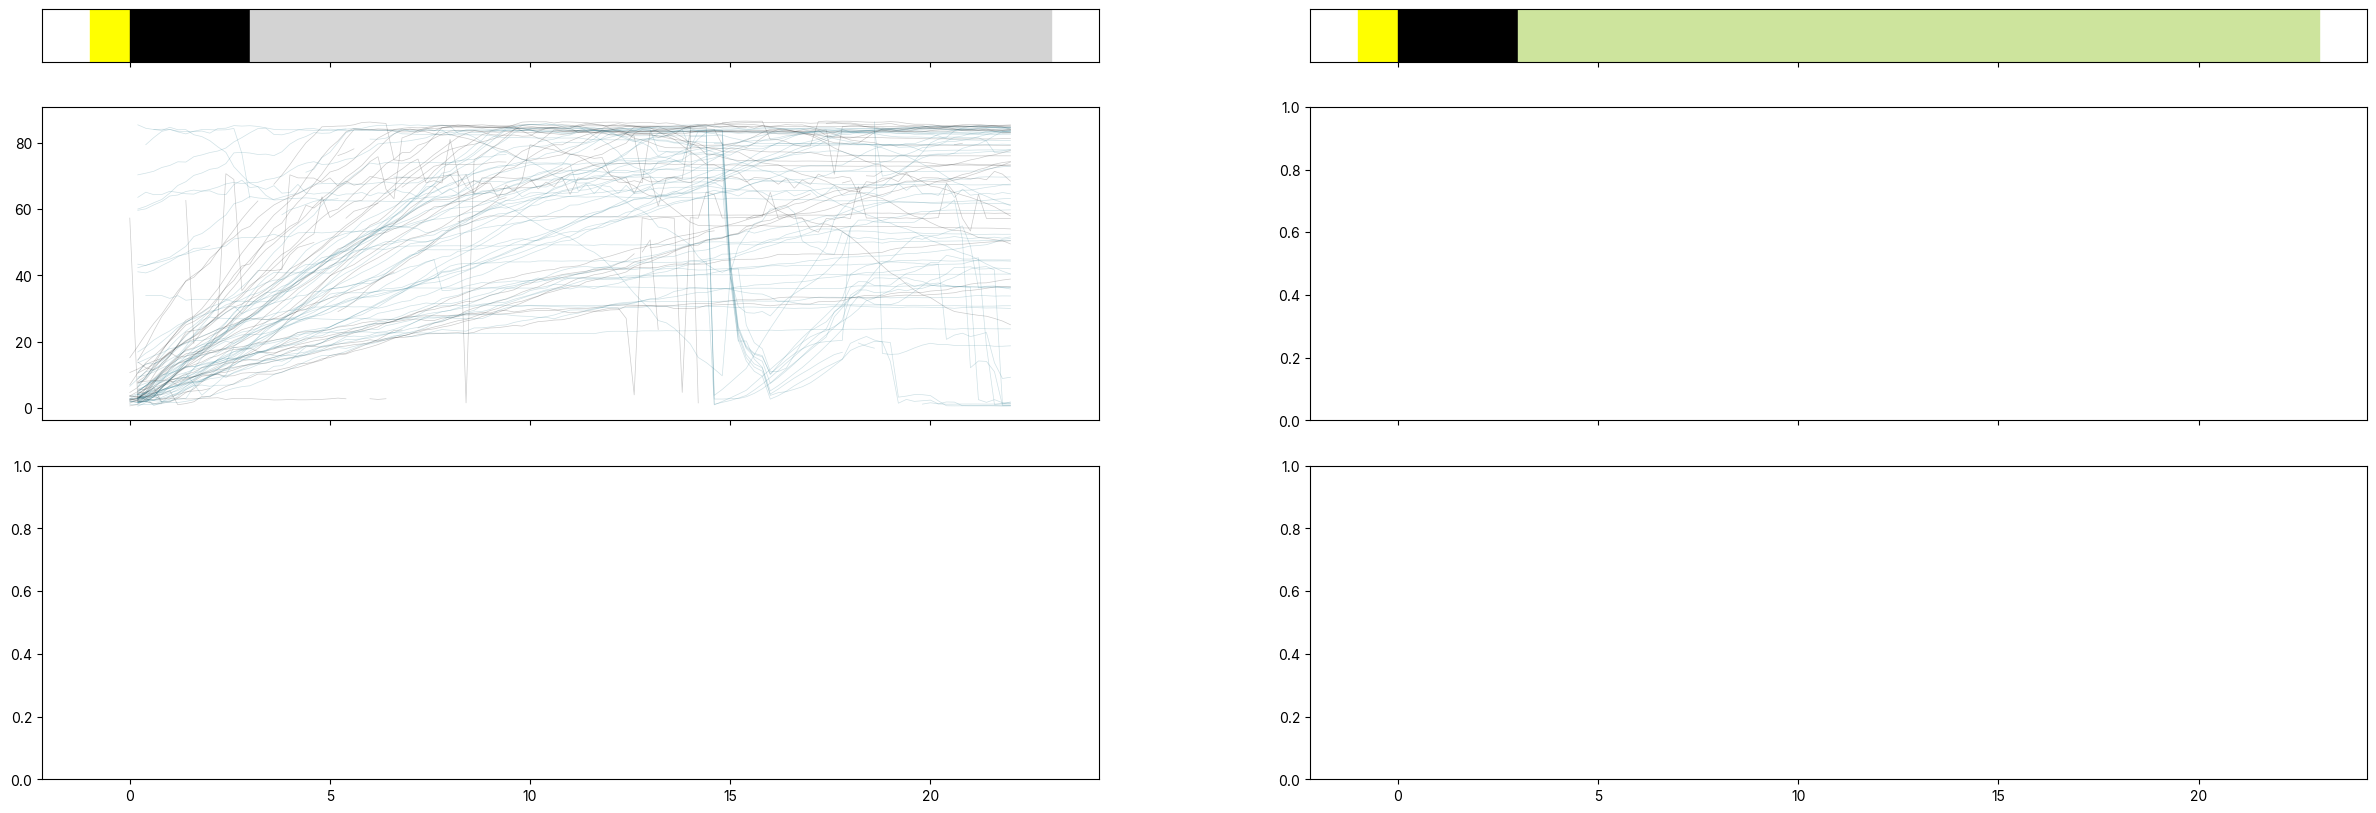

In [25]:
figthirdplot, axs = plt.subplots(3, 2, figsize=(30, 10 ),sharex = "col", gridspec_kw={'height_ratios': [1, 6, 6]}) #sharey = row

#dist
dfy_exptall_dark = removingextraline(df_de[df_de.ExperimentState =="Dark"])
dfy_exptall_full = removingextraline(df_de[df_de.ExperimentState =="Full"])
dfy_wtall_dark = removingextraline(df_dw[df_dw.ExperimentState =="Dark"])
dfy_wtall_full = removingextraline(df_dw[df_dw.ExperimentState =="Full"])

#speed
dfs_exptall_dark = removingextraline(df_se[df_se.ExperimentState =="Dark"])
dfs_exptall_full = removingextraline(df_se[df_se.ExperimentState =="Full"])
dfs_wtall_dark = removingextraline(df_sw[df_sw.ExperimentState =="Dark"])
dfs_wtall_full = removingextraline(df_sw[df_sw.ExperimentState =="Full"])

#mean curves
df3 = removingextraline(df_meande)
df4 = removingextraline(df_meandw)
df5 = removingextraline(df_meanse)
df6 = removingextraline(df_meansw)

driver = transgenic
nnumber = int(0.20*(len(dfexpt.columns)-2))
nnumberwt = int(0.20*(len(dfwt.columns)-2))
time = df3.loc[df3.ExperimentState == "Dark", 'Seconds']
time2 = df4.loc[df4.ExperimentState == "Dark", 'Seconds']

if "ACR" in responder:
    barcolr = "#1f9c19"
    patchcolor = "#c5e384"
    compdark = "#905513"
    complight = "#ff9926"
    #meanline = "#1f9c19"
    meanline = "#a86e22"
    
    
if "Chrimson2" in responder:
    barcolr = "#c30010"
    patchcolor = "salmon"
    compdark = "#7d00c7"
    complight = "#ca8dff"
    #meanline = "#c30010"
    meanline = "#6653f5"

#cartoon
axs[0,0].axvspan(-1,0, color = "#FFFF00", label = "_nolegend_")
axs[0,0].axvspan(0,3, color = "#000000", label = "_nolegend_")
axs[0,0].axvspan(3,23, color = "lightgray" , label = "_nolegend_")

axs[0,1].axvspan(-1,0, color = "#FFFF00" , label = "_nolegend_")
axs[0,1].axvspan(0,3, color = "#000000", label = "_nolegend_")
axs[0,1].axvspan(3,23, color = patchcolor, label = "_nolegend_")


axs[0,0].get_yaxis().set_visible(False)
axs[0,1].get_yaxis().set_visible(False)



#y pos    

#axs[1,0].axvspan(3,23, alpha=0.1, color = "#000000", label = "_nolegend_")
axs[1,0].plot(dfy_exptall_dark['Seconds'], dfy_exptall_dark.iloc[:,2:], color = barcolr, alpha = 0.2, linewidth = 0.5, label = "driver", zorder = 2)
axs[1,0].plot(dfy_wtall_dark['Seconds'], dfy_wtall_dark.iloc[:,2:], color = "#000000", alpha = 0.2, linewidth =0.5, label = "w1118 controls", zorder = 1)

#mean
axs[1,0].plot(time, df3.loc[df3.ExperimentState == "Dark", 'mean'], color = meanline, linewidth = 3, label = "_nolegend_")
axs[1,0].plot(time, df4.loc[df4.ExperimentState == "Dark", 'mean'], color = "#000000", linewidth =3, label = "_nolegend_")
axs[1,1].plot(time, df3.loc[df3.ExperimentState == "Full", 'mean'], color = meanline, linewidth = 3, label = "_nolegend_")
axs[1,1].plot(time, df4.loc[df4.ExperimentState == "Full", 'mean'], color = "#000000", linewidth =3, label = "_nolegend_")


axs[1,0].set(xlabel='Time(seconds)', ylabel='Individual Y positions (mm)')
axs[1,1].set(xlabel='Time(seconds)')

axs[1,1].plot(dfy_exptall_full['Seconds'], dfy_exptall_full.iloc[:,2:],color = barcolr,alpha = 0.2,linewidth = 0.5, label = "_nolegend_", zorder = 2)
#axs[1,1].plot(dfy_wtall_full['Seconds'], dfy_wtall_full.iloc[:,2:], color = "#000000", alpha =0.2, linewidth =0.5, label = "_nolegend_", zorder = 1)

#together with differences

axs[1,0].set_ylim([0, 85])
axs[1,1].set_ylim([0, 85])


#speed

axs[2,0].plot(dfs_exptall_dark['Seconds'], dfs_exptall_dark.iloc[:,2:], color = barcolr, alpha = 0.2,linewidth = 0.5, label = "_nolegend_", zorder = 2)
axs[2,0].plot(dfs_wtall_dark['Seconds'], dfs_wtall_dark.iloc[:,2:], color = "#000000", alpha = 0.1,linewidth =0.5, label = "_nolegend_", zorder = 1)
axs[2,0].set(xlabel='Time(seconds)', ylabel='Individual Speed (mm/s)')
axs[2,1].set(xlabel='Time(seconds)')

axs[2,1].plot(dfs_exptall_full['Seconds'], dfs_exptall_full.iloc[:,2:], color = barcolr, linewidth = 0.2, alpha = 0.25, zorder = 2, label = "_nolegend_")
#axs[2,1].plot(dfs_wtall_full['Seconds'], dfs_wtall_full.iloc[:,2:], color = "#000000", alpha = 0.1,linewidth =0.5, zorder = 1, label = "_nolegend_")

#mean

axs[2,0].plot(time, df5.loc[df5.ExperimentState == "Dark", 'mean'], color = meanline, linewidth = 3, label = "_nolegend_")
axs[2,0].plot(time, df6.loc[df6.ExperimentState == "Dark", 'mean'], color = "#000000", linewidth =3, label = "_nolegend_")

axs[2,1].plot(time, df5.loc[df5.ExperimentState == "Full", 'mean'], color = meanline, linewidth = 3, label = "_nolegend_")
axs[2,1].plot(time, df6.loc[df6.ExperimentState == "Full", 'mean'], color = "#000000", linewidth =3, label = "_nolegend_")


axs[2,0].set_ylim([0, 40])
axs[2,1].set_ylim([0, 40])

#Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
    ax.set_xlim([-1,23])

    
figthirdplot.suptitle(t = "Individual line plots of " + driver  + " (n= " + str(nnumber) + ")", fontweight='bold', x = 0.1)

#legend
from matplotlib.lines import Line2D

custom_lines = [Line2D([0], [0], color = barcolr, lw=2),
                Line2D([0], [0], color="#000000", lw=2),
                Line2D([0], [0], color=compdark, lw=2),
                Line2D([0], [0], color=complight, lw=2)]
labels = [driver, "w1118 controls", driver +"_dark", driver + "_light"]
figthirdplot.legend(custom_lines, labels, loc='lower right', bbox_to_anchor=(1,0.95), ncol=4, bbox_transform=figthirdplot.transFigure, prop={'size': 12})


figthirdplot.tight_layout()

figthirdplot.show()